In [13]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx", sheet_name = 16,header=None)
df = df.drop(columns =[0])

df = df.iloc[7:].reset_index(drop=True) #removing 1 to 6 th rows
df = df.iloc[:-4].reset_index(drop=True)

# replacing - with nan
df = df.replace('-', np.nan)

df.head()


/tmp/ipykernel_2791/4243878944.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,1,2,3,4,5,6,7,8,9
0,1.0,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2.0,Cardamom,7936.619600,3907.678400,7674.036648,4557.068808,7199.503800,16.618318,57.985409
2,3.0,Cattlefeed,0.061000,0.061000,0.000000,0.000000,0.000000,NaN,NaN
3,4.0,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.693420,-25.879216,-22.109289
4,5.0,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


In [14]:
df.columns = [
    'S.N.',
    'Product',
    '2023/24 Annual',
    '2023/24 Six Months',
    '2024/25 Annual',
    '2024/25 Six Months',
    '2025/26 Six Months',
    '2024/25 Growth %',
    '2025/26 Growth %'
]
df.head()



,S.N.,Product,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1.0,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2.0,Cardamom,7936.619600,3907.678400,7674.036648,4557.068808,7199.503800,16.618318,57.985409
2,3.0,Cattlefeed,0.061000,0.061000,0.000000,0.000000,0.000000,NaN,NaN
3,4.0,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.693420,-25.879216,-22.109289
4,5.0,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


In [15]:
df.describe()

,S.N.,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
count,36.000000,38.000000,38.000000,38.000000,38.000000,38.000000,35.000000,34.000000
mean,18.500000,2337.280902,1166.861091,5143.959719,1633.664173,2701.405627,2.955624,34.522393
std,10.535654,3142.582309,1544.027873,17236.057580,3282.766199,9060.125140,63.976554,69.687770
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-79.408446,-84.435554
25%,9.750000,186.556738,83.248302,134.883369,71.426585,69.181395,-31.963662,-5.184653
50%,18.500000,918.596312,433.550019,1045.545997,426.629591,592.672471,-5.986111,23.209987
75%,27.250000,2895.643997,1455.701328,3495.183627,1724.537805,1683.819268,22.475967,65.193683
max,36.000000,11858.045690,6085.189136,106790.819514,18909.958030,56082.425848,277.525349,196.576152


In [16]:
# checking empty data or data handling
print(df.isnull().sum())

# checking du-plicates data
print(df.duplicated().sum())

S.N.                  2
Product               0
2023/24 Annual        0
2023/24 Six Months    0
2024/25 Annual        0
2024/25 Six Months    0
2025/26 Six Months    0
2024/25 Growth %      3
2025/26 Growth %      4
dtype: int64
0


In [101]:
top5_export_2023_2024 = df.nlargest(5, '2023/24 Annual')[['Product', '2023/24 Annual']]
print(top5_export_2023_2024)

top5_export_2024_2025 = df.nlargest(5, '2024/25 Annual')[['Product', '2024/25 Annual']]
print(top5_export_2024_2025)

top5_export_2023_2024_SixMonths = df.nlargest(5, '2023/24 Six Months')[['Product', '2023/24 Six Months']]
print(top5_export_2023_2024_SixMonths)

top5_export_2024_2025_SixMonths = df.nlargest(5, '2024/25 Six Months')[['Product', '2024/25 Six Months']]
print(top5_export_2024_2025_SixMonths)

top5_export_2025_2026_SixMonths = df.nlargest(5, '2025/26 Six Months')[['Product', '2025/26 Six Months']]
print(top5_export_2025_2026_SixMonths)

bottom5 = df.nsmallest(5, '2025/26 Six Months')[['Product', '2025/26 Six Months']]
print(bottom5)



           Product  2023/24 Annual
37      Zinc sheet    11858.045690
24   Polyster Yarn     9382.523442
10           Juice     8658.685444
1         Cardamom     7936.619600
21  Particle Board     7415.322247
          Product  2024/25 Annual
29   Soyabean Oil   106790.819514
24  Polyster Yarn    12335.018810
37     Zinc sheet    10108.486376
11     Jute Goods     8222.942050
10          Juice     7703.781897
          Product  2023/24 Six Months
37     Zinc sheet         6085.189136
24  Polyster Yarn         4548.345933
1        Cardamom         3907.678400
10          Juice         3760.637317
11     Jute Goods         3625.598887
           Product  2024/25 Six Months
29    Soyabean Oil        18909.958030
24   Polyster Yarn         5925.106407
1         Cardamom         4557.068808
37      Zinc sheet         4515.373418
21  Particle Board         4249.220775
          Product  2025/26 Six Months
29   Soyabean Oil        56082.425848
1        Cardamom         7199.503800
24  Polyst

In [103]:
top20 = df.nlargest(20, '2025/26 Six Months')

In [18]:

num_cols = ['2023/24 Six Months', '2024/25 Six Months', '2025/26 Six Months']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Reshape for plotly line chart
top5 = df.nlargest(5, '2025/26 Six Months')
df_melted = top5.melt(
    id_vars='Product',
    value_vars=num_cols,
    var_name='Period',
    value_name='Export Value'
)

# Plot
fig = px.line(df_melted, x='Period', y='Export Value',
              color='Product', markers=True,
              title='Six Month Export Trends — Top 5 Commodities')
fig.show()

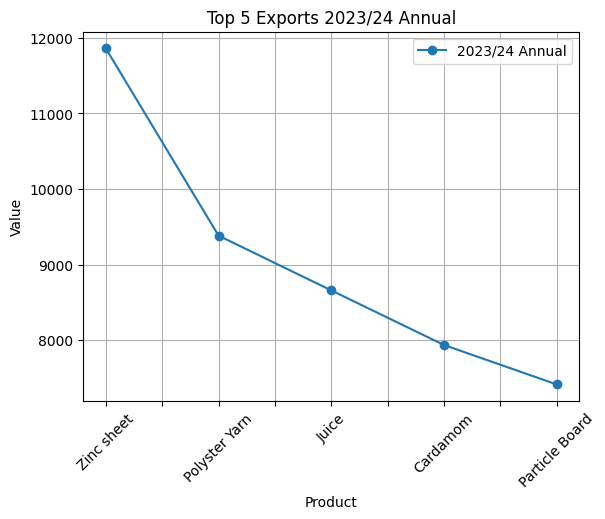

In [19]:
import matplotlib.pyplot as plt

top5_export_2023_2024.set_index('Product').plot(kind='line', marker='o')
plt.title('Top 5 Exports 2023/24 Annual')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [40]:
print(df.columns.tolist())

['S.N.', 'Product', '2023/24 Annual', '2023/24 Six Months', '2024/25 Annual', '2024/25 Six Months', '2025/26 Six Months', '2024/25 Growth %', '2025/26 Growth %']


In [46]:
df_sorted = df.sort_values(
    by=['2023/24 Annual', '2023/24 Six Months', '2024/25 Annual', '2024/25 Six Months', '2025/26 Six Months'],
    ascending=False
)

df_sorted.head()

,S.N.,Product,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
37,36.0,Zinc sheet,11858.045690,6085.189136,10108.486376,4515.373418,702.792862,-25.797320,-84.435554
24,23.0,Polyster Yarn,9382.523442,4548.345933,12335.018810,5925.106407,5658.460047,30.269476,-4.500280
10,11.0,Juice,8658.685444,3760.637317,7703.781897,3450.357905,3489.129565,-8.250714,1.123700
1,2.0,Cardamom,7936.619600,3907.678400,7674.036648,4557.068808,7199.503800,16.618318,57.985409
21,20.0,Particle Board,7415.322247,3530.322941,7099.647606,4249.220775,2157.522718,20.363515,-49.225450


In [62]:
Q1 = df['2023/24 Annual'].quantile(0.25)
Q3 = df['2023/24 Annual'].quantile(0.75)
IQR = Q3 - Q1
IQR

df_clean = df[(df['2023/24 Annual'] >= Q1 - 1.5 * IQR) &
              (df['2023/24 Annual'] <= Q3 + 1.5 * IQR)]

df_clean.head()

,S.N.,Product,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1.0,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
2,3.0,Cattlefeed,0.061000,0.061000,0.000000,0.000000,0.000000,NaN,NaN
3,4.0,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.693420,-25.879216,-22.109289
4,5.0,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294
5,6.0,Fruits,16.845366,4.444210,8.545120,5.055800,12.872260,13.761501,154.603821


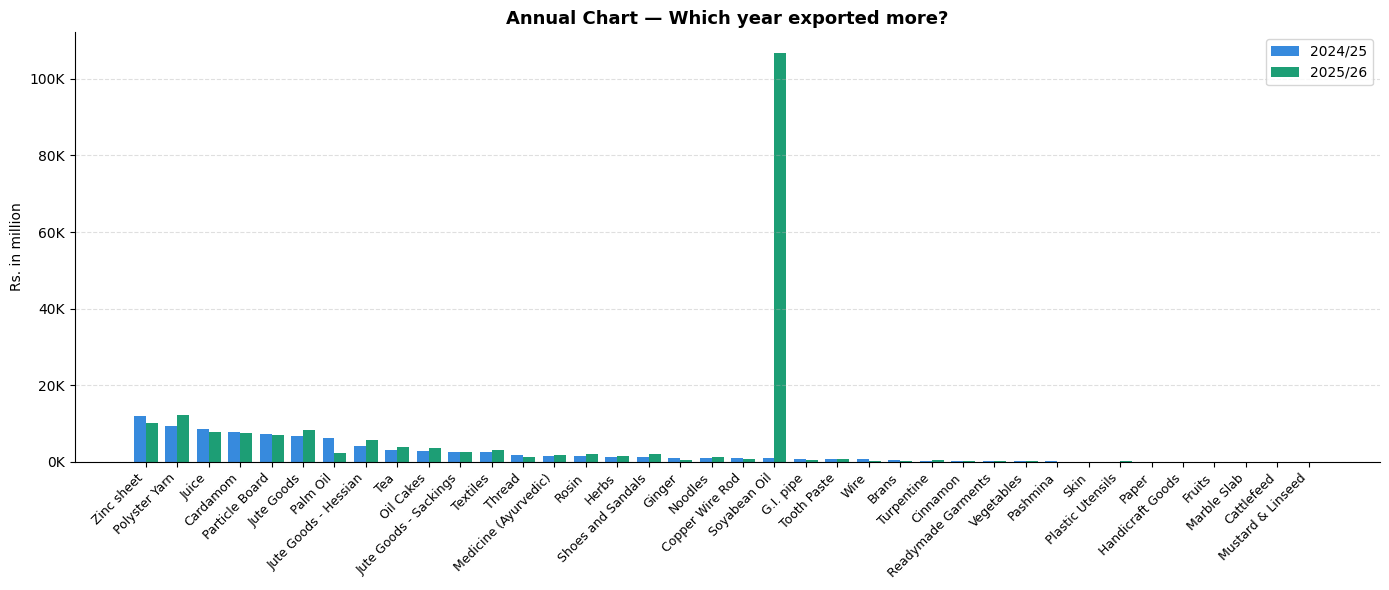

In [71]:


# Grouped bar — which year exported more?
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df))
w = 0.38
ax.bar(x - w/2, df_sorted['2023/24 Annual'], w, label='2024/25', color='#378ADD')
ax.bar(x + w/2, df_sorted['2024/25 Annual'], w, label='2025/26', color='#1D9E75')

ax.set_xticks(x)
ax.set_xticklabels(df_sorted['Product'], rotation=45, ha='right', fontsize=9)
ax.set_title('Annual Chart — Which year exported more?', fontsize=13, fontweight='bold')
ax.set_ylabel('Rs. in million')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

,S.N.,Product,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1.0,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
2,3.0,Cattlefeed,0.061000,0.061000,0.000000,0.000000,0.000000,NaN,NaN
3,4.0,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.693420,-25.879216,-22.109289
4,5.0,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294
5,6.0,Fruits,16.845366,4.444210,8.545120,5.055800,12.872260,13.761501,154.603821


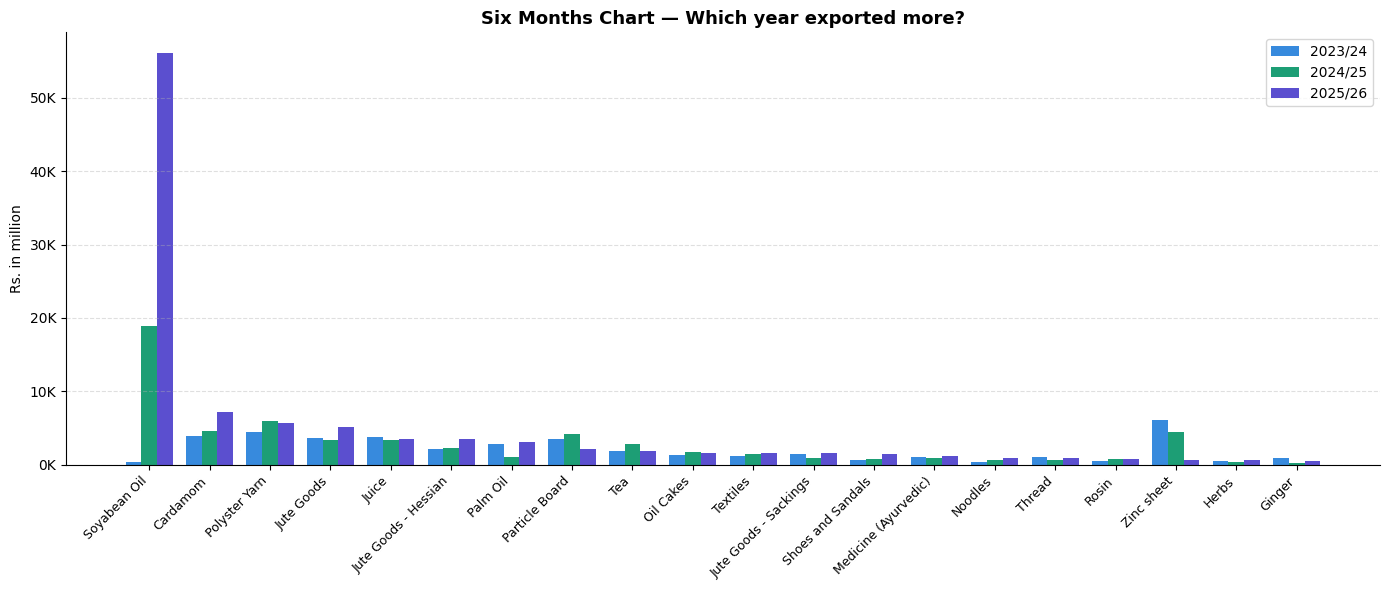

In [100]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top5))
w = 0.26  # narrower width to fit 3 bars

ax.bar(x - w,     top5['2023/24 Six Months'], w, label='2023/24', color='#378ADD')
ax.bar(x,         top5['2024/25 Six Months'], w, label='2024/25', color='#1D9E75')
ax.bar(x + w,     top5['2025/26 Six Months'], w, label='2025/26', color='#5B4FCF')

ax.set_xticks(x)
ax.set_xticklabels(top5['Product'], rotation=45, ha='right', fontsize=9)
ax.set_title('Six Months Chart — Which year exported more?', fontsize=13, fontweight='bold')
ax.set_ylabel('Rs. in million')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

,S.N.,Product,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
37,36.0,Zinc sheet,11858.045690,6085.189136,10108.486376,4515.373418,702.792862,-25.797320,-84.435554
24,23.0,Polyster Yarn,9382.523442,4548.345933,12335.018810,5925.106407,5658.460047,30.269476,-4.500280
10,11.0,Juice,8658.685444,3760.637317,7703.781897,3450.357905,3489.129565,-8.250714,1.123700
1,2.0,Cardamom,7936.619600,3907.678400,7674.036648,4557.068808,7199.503800,16.618318,57.985409
21,20.0,Particle Board,7415.322247,3530.322941,7099.647606,4249.220775,2157.522718,20.363515,-49.225450


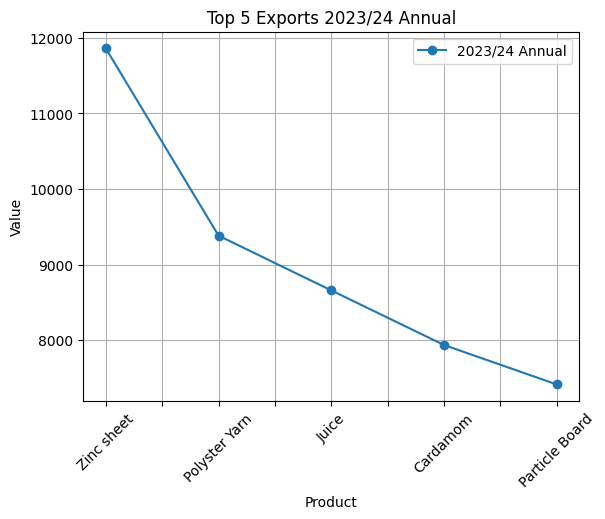

In [20]:
import matplotlib.pyplot as plt

top5_export_2023_2024.set_index('Product').plot(kind='line', marker='o')
plt.title('Top 5 Exports 2023/24 Annual')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

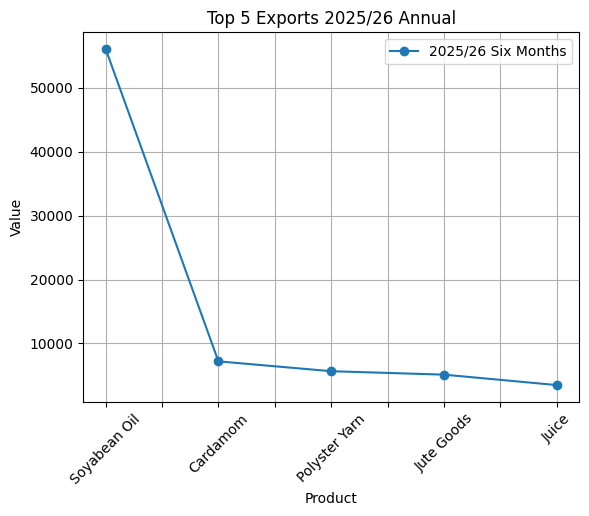

In [21]:
import matplotlib.pyplot as plt

top5_export_2025_2026_SixMonths.set_index('Product').plot(kind='line', marker='o')
plt.title('Top 5 Exports 2025/26 Annual')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [23]:
cov = df[['2024/25 Growth %', '2025/26 Growth %']].cov().round(2)
print(cov)

cov = df[['2023/24 Six Months', '2024/25 Six Months',
          '2025/26 Six Months']].cov().round(2)
print(cov)

                  2024/25 Growth %  2025/26 Growth %
2024/25 Growth %           4093.00          -1356.79
2025/26 Growth %          -1356.79           4856.39
                    2023/24 Six Months  2024/25 Six Months  2025/26 Six Months
2023/24 Six Months          2384022.07          1923501.70           908312.13
2024/25 Six Months          1923501.70         10776553.92         27848865.49
2025/26 Six Months           908312.13         27848865.49         82085867.56


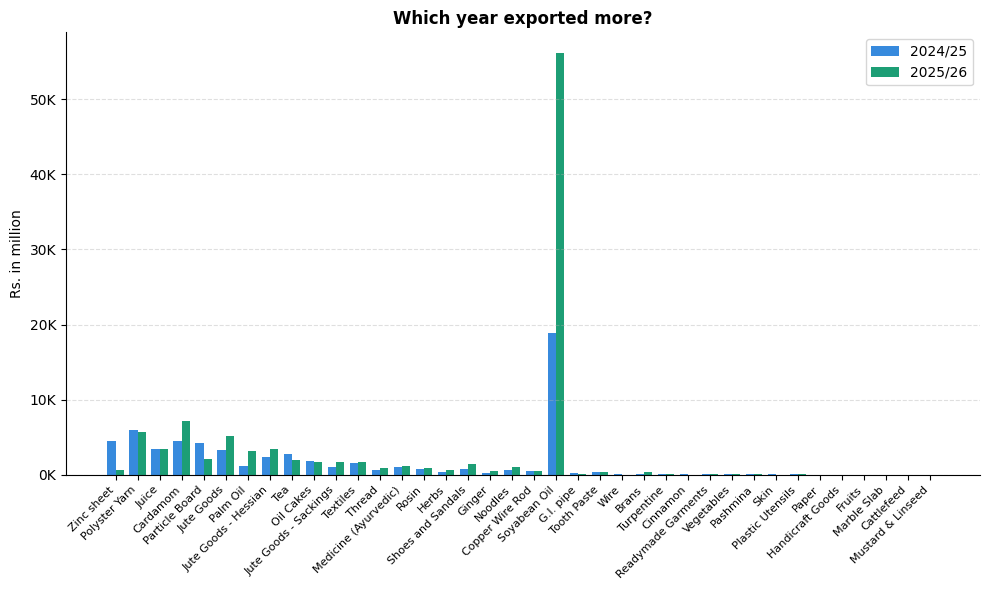

In [31]:
plt.figure(figsize=(10,6))

x = np.arange(len(df2))
w = 0.38

plt.bar(x - w/2, df2['2024/25 Six Months'], w, label='2024/25', color='#378ADD')
plt.bar(x + w/2, df2['2025/26 Six Months'], w, label='2025/26', color='#1D9E75')

plt.xticks(x, df2['Product'], rotation=45, ha='right', fontsize=8)
plt.title('Which year exported more?', fontweight='bold')
plt.ylabel('Rs. in million')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()





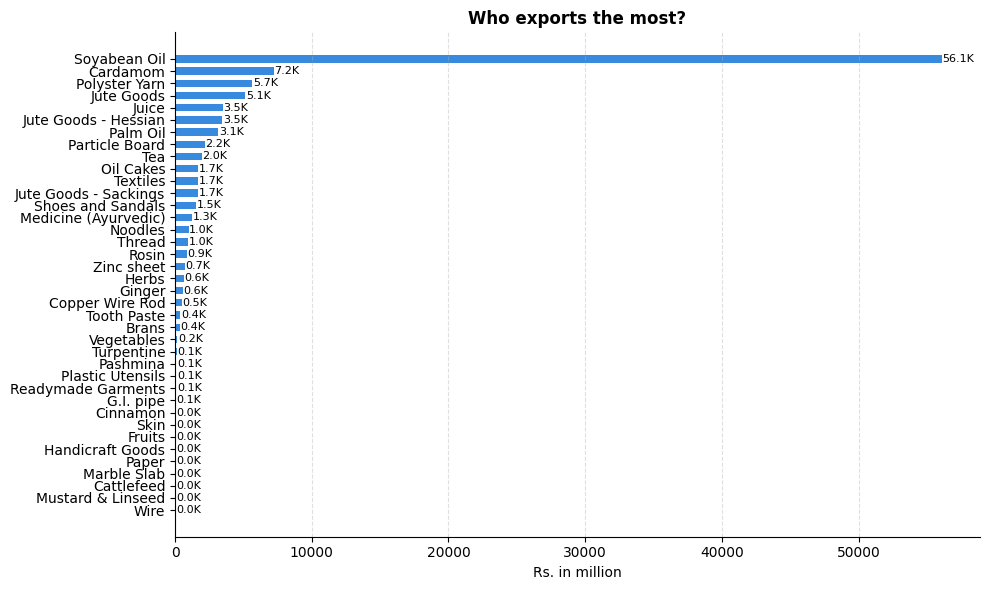

In [67]:
plt.figure(figsize=(10,6))

df_rank = df_sorted.sort_values('2025/26 Six Months')

plt.barh(df_rank['Product'], df_rank['2025/26 Six Months'],
         color='#378ADD', height=0.6)

for i, v in enumerate(df_rank['2025/26 Six Months']):
    plt.text(v + 50, i, f'{v/1000:.1f}K', va='center', fontsize=8)

plt.title('Who exports the most?', fontweight='bold')
plt.xlabel('Rs. in million')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [97]:
import plotly.express as px

top5 = df.nlargest(5, '2025/26 Six Months').copy()
others = pd.DataFrame([{
    'Product': 'Others',
    '2025/26 Six Months': df['2025/26 Six Months'].sum() - top5['2025/26 Six Months'].sum()
}])

df_pie = pd.concat([top5, others], ignore_index=True)

fig = px.pie(
    df_pie,
    values='2025/26 Six Months',
    names='Product',
    title='Market Share of Exports —2025/26 Six Months',
    color_discrete_sequence=['red','blue','yellow','green','orange','brown']
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [98]:
import plotly.express as px

top5 = df.nlargest(5, '2023/24 Annual').copy()
others = pd.DataFrame([{
    'Product': 'Others',
    '2023/24 Annual': df['2023/24 Annual'].sum() - top5['2023/24 Annual'].sum()
}])

df_pie = pd.concat([top5, others], ignore_index=True)

fig = px.pie(
    df_pie,
    values='2023/24 Annual',
    names='Product',
    title='Market Share of Exports —2023/24 Annual',
        color_discrete_sequence=['red','blue','yellow','green','orange','brown']
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [99]:
import plotly.express as px

top5 = df.nlargest(5, '2024/25 Annual').copy()
others = pd.DataFrame([{
    'Product': 'Others',
    '2024/25 Annual': df['2024/25 Annual'].sum() - top5['2024/25 Annual'].sum()
}])

df_pie = pd.concat([top5, others], ignore_index=True)

fig = px.pie(
    df_pie,
    values='2024/25 Annual',
    names='Product',
    title='Market Share of Exports — 2024/25 Annual',
        color_discrete_sequence=['red','blue','yellow','green','orange','brown']

)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [78]:
df.columns.tolist()

['S.N.',
 'Product',
 '2023/24 Annual',
 '2023/24 Six Months',
 '2024/25 Annual',
 '2024/25 Six Months',
 '2025/26 Six Months',
 '2024/25 Growth %',
 '2025/26 Growth %']